# Waze User Churn Project

## Company Background:

Waze’s free navigation app makes it easier for drivers around the world to get to where they want to go. Waze’s community of map editors, beta testers, translators, partners, and users helps make each drive better and safer. Waze partners with cities, transportation authorities, broadcasters, businesses, and first responders to help as many people as possible travel more efficiently and safely. 

I’ll analyze and interpret data, generate valuable insights, and help leadership make informed business decisions. My team is about to start a new project to help prevent user churn on the Waze app. Churn quantifies the number of users who have uninstalled the Waze app or stopped using the app. This project focuses on monthly user churn. I will analyze user data and develop a machine learning model that predicts user churn. 

This project is part of a larger effort at Waze to increase growth. Typically, high retention rates indicate satisfied users who repeatedly use the Waze app over time. Developing a churn prediction model will help prevent churn, improve user retention, and grow Waze’s business. An accurate model can also help identify specific factors that contribute to churn and answer questions such as: 

Who are the users most likely to churn?

- Why do users churn? 

- When do users churn? 

For example, if Waze can identify a segment of users who are at high risk of churning, Waze can proactively engage these users with special offers to try and retain them. Otherwise, Waze may simply lose these users without knowing why. 

Your insights will help Waze leadership optimize the company’s retention strategy, enhance user experience, and make data-driven decisions about product development.  

### Contents:
1. Preliminary Data Summary
2. Exploratory Data Analysis
3. Hypothesis Testing
4. Regression Analysis
5. Building a Machine Learning Model
6. Conclusions and Business Recommendations

### __1. Preliminary Data Summary__

**Introduction**

The goal of this project is to predict user churn for Waze using historical driving data. Churn quantifies the number of users who have uninstalled the Waze app or stopped using the app. This project focuses on mothly user churn. We will analyze user data and develope a machine learning model that predicts user churn. High retention rates indicate satisfied user who repeteadly use the Waze app over time. Developing a churn prediction model will help prevent churn, improve user etention nd grow Waze's business.

**Objective**

The objective is to develop a machine learning model that will accurately predict and identify the key factors that contribute to user churn. Developing a churn prediction model will help prevent churn, improve user retention, and grow Waze's businees.

**Summary**

In this project, I analysed driving behaviour data to prediction user churn for Waze. I performed EDA, handled missing values and outliers, and built classification models to predict churn. By improving the app experience for professional drivers, increasing engagement for low-activity users, and anlysing the insights to create personalized retention strategies, Waze can significantly reduce churn and increase long-term user retention. These insight provide actionable steps for Waze to retain its most valuable users.

**Imports and data loading**

In [155]:
# Import packages for data manipulation
import pandas as pd
import numpy as np
from scipy import stats

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# Packages for Logistic Regression and Confusion Matrix
import sklearn.metrics as metrics
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Import packages for data modeling
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, classification_report

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# This is the function that helps plot feature importance
from xgboost import plot_importance

# # This module lets us save our models once we fit them.
import pickle

In [4]:
# Load dataset into dataframe
df = pd.read_csv('waze_dataset.csv')

**Summary information**

In [5]:
df.head(10)

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android
5,5,retained,113,103,279.544437,2637,0,0,901.238699,439.101397,15,11,iPhone
6,6,retained,3,2,236.725314,360,185,18,5249.172828,726.577205,28,23,iPhone
7,7,retained,39,35,176.072845,2999,0,0,7892.052468,2466.981741,22,20,iPhone
8,8,retained,57,46,183.532018,424,0,26,2651.709764,1594.342984,25,20,Android
9,9,churned,84,68,244.802115,2997,72,0,6043.460295,2341.838528,7,3,iPhone


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


In [7]:
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


**Null values and summary statistics**

In [9]:
df.isnull().sum()

ID                           0
label                      700
sessions                     0
drives                       0
total_sessions               0
n_days_after_onboarding      0
total_navigations_fav1       0
total_navigations_fav2       0
driven_km_drives             0
duration_minutes_drives      0
activity_days                0
driving_days                 0
device                       0
dtype: int64

We compare the summary statistics of the 700 rows that are missing labels with summary statistics of the rows that are not missing any values.

In [10]:
# Isolate rows with null values
df_null=df[df['label'].isnull()]

# Display summary stats of rows with null values
df_null.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,7405.584286,80.837143,67.798571,198.483348,1709.295714,118.717143,30.371429,3935.967029,1795.123358,15.382857,12.125714
std,4306.900234,79.987440,65.271926,140.561715,1005.306562,156.308140,46.306984,2443.107121,1419.242246,8.772714,7.626373
min,77.000000,0.000000,0.000000,5.582648,16.000000,0.000000,0.000000,290.119811,66.588493,0.000000,0.000000
25%,3744.500000,23.000000,20.000000,94.056340,869.000000,4.000000,0.000000,2119.344818,779.009271,8.000000,6.000000
50%,7443.000000,56.000000,47.500000,177.255925,1650.500000,62.500000,10.000000,3421.156721,1414.966279,15.000000,12.000000
75%,11007.000000,112.250000,94.000000,266.058022,2508.750000,169.250000,43.000000,5166.097373,2443.955404,23.000000,18.000000
max,14993.000000,556.000000,445.000000,1076.879741,3498.000000,1096.000000,352.000000,15135.391280,9746.253023,31.000000,30.000000


In [16]:
# Isolate rows without null values
df_not_null=df[df['label'].notnull()]

# Display summary stats of rows without null values
df_not_null.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,7503.573117,80.623820,67.255822,189.547409,1751.822505,121.747395,29.638296,4044.401535,1864.199794,15.544653,12.182530
std,4331.207621,80.736502,65.947295,136.189764,1008.663834,147.713428,45.350890,2504.977970,1448.005047,9.016088,7.833835
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000
50%,7504.000000,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000
75%,11257.500000,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


There is not a significant difference between the two populations, only the row numbers.

**Null values-device counts**

Now, I check the two populations with respect to the `device` variable.

In [17]:
# Get count of null values by device
print('Null values for iPhone users: ', sum(df_null['device']=='iPhone'))
print('Null values for Android users: ', sum(df_null['device']=='Android'))

Null values for iPhone users:  447
Null values for Android users:  253


Now, of the rows with null values, I calculate the percentage with each device&mdash;Android and iPhone.


In [18]:
df_null['device'].value_counts(normalize=True)

device
iPhone     0.638571
Android    0.361429
Name: proportion, dtype: float64

How does this compare to the device ratio in the full dataset?

In [19]:
df_not_null['device'].value_counts(normalize=True)

device
iPhone     0.64515
Android    0.35485
Name: proportion, dtype: float64

	
The percentage of missing values by each device is consistent with their representation in the data overall. There is nothing to suggest a non-random cause of the missing data.

Now, I examine the counts and percentages of users who churned vs. those who were retained. How many of each group are represented in the data?

In [22]:
# Calculate counts of churned vs. retained
df['label'].value_counts(normalize=True)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

This dataset contains 82% retained users and 18% churned users.

Next, I compare the medians of each variable for churned and retained users. The reason for calculating the median and not the mean is that you don't want outliers to unduly affect the portrayal of a typical user. Notice, for example, that the maximum value in the `driven_km_drives` column is 21,183 km. That's more than half the circumference of the earth!


In [24]:
print('Churned median: ', df[df['label']=='churned'].median(numeric_only=True))
print('Retained median: ', df[df['label']=='retained'].median(numeric_only=True))

Churned median:  ID                         7477.500000
sessions                     59.000000
drives                       50.000000
total_sessions              164.339042
n_days_after_onboarding    1321.000000
total_navigations_fav1       84.500000
total_navigations_fav2       11.000000
driven_km_drives           3652.655666
duration_minutes_drives    1607.183785
activity_days                 8.000000
driving_days                  6.000000
dtype: float64
Retained median:  ID                         7509.000000
sessions                     56.000000
drives                       47.000000
total_sessions              157.586756
n_days_after_onboarding    1843.000000
total_navigations_fav1       68.000000
total_navigations_fav2        9.000000
driven_km_drives           3464.684614
duration_minutes_drives    1458.046141
activity_days                17.000000
driving_days                 14.000000
dtype: float64


This offers an interesting snapshot of the two groups, churned vs. retained:
 
Users who churned averaged ~3 more drives in the last month than retained users, but retained users used the app on over twice as many days as churned users in the same time period.
 
The median churned user drove ~200 more kilometers and 2.5 more hours during the last month than the median retained user.
 
It seems that churned users had more drives in fewer days, and their trips were farther and longer in duration. Perhaps this is suggestive of a user profile.

Calculate the median kilometers per drive in the last month for both retained and churned users.
 
Begin by dividing the `driven_km_drives` column by the `drives` column. Then, group the results by churned/retained and calculate the median km/drive of each group.


In [ ]:
# Add a column to df called `km_per_drive`
df['km_per_drive']=df['driven_km_drives']/df['drives']
# Group by `label`, calculate the median, and isolate for km per drive
df.groupby('label').agg({'km_per_drive': 'median'})

,km_per_drive
label,
churned,74.109416
retained,75.014702


The median retained user drove about one more kilometer per drive than the median churned user. How many kilometers per driving day was this?

In [27]:
# Add a column to df called `km_per_driving_day`
df['km_per_driving_day']=df['driven_km_drives']/df['driving_days']

# Group by `label`, calculate the median, and isolate for km per driving day
df.groupby('label').agg({'km_per_driving_day':'median'})


,km_per_driving_day
label,
churned,697.541999
retained,289.549333


Now, I calculate the median number of drives per driving day for each group.


In [28]:
# Add a column to df called `drives_per_driving_day`
df['drives_per_driving_day']=df['drives']/df['driving_days']

# Group by `label`, calculate the median, and isolate for drives per driving day
df.groupby('label').agg({'drives_per_driving_day': 'median'})

,drives_per_driving_day
label,
churned,10.0000
retained,4.0625


The median user who churned drove 698 kilometers each day they drove last month, which is almost ~240% the per-drive-day distance of retained users. The median churned user had a similarly disproporionate number of drives per drive day compared to retained users.
 
It is clear from these figures that, regardless of whether a user churned or not, the users represented in this data are serious drivers! It would probably be safe to assume that this data does not represent typical drivers at large. Perhaps the data&mdash;and in particular the sample of churned users&mdash;contains a high proportion of long-haul truckers.
 
In consideration of how much these users drive, it would be worthwhile to recommend to Waze that they gather more data on these super-drivers. It's possible that the reason for their driving so much is also the reason why the Waze app does not meet their specific set of needs, which may differ from the needs of a more typical driver, such as a commuter.

Finally, examine whether there is an imbalance in how many users churned by device type.
 
Begin by getting the overall counts of each device type for each group, churned and retained.

In [29]:
df[['label','device']].value_counts()

label     device 
retained  iPhone     7580
          Android    4183
churned   iPhone     1645
          Android     891
Name: count, dtype: int64

Now, within each group, churned and retained, I calculate what percent was Android and what percent was iPhone.

In [30]:
df[['label','device']].value_counts(normalize=True)

label     device 
retained  iPhone     0.530107
          Android    0.292538
churned   iPhone     0.115043
          Android    0.062312
Name: proportion, dtype: float64

 The ratio of iPhone users and Android users is consistent between the churned group and the retained group, and those ratios are both consistent with the ratio found in the overall dataset.

**Questions:**

1. Did the data contain any missing values? How many, and which variables were affected? Was there a pattern to the missing data?

Data contains missing values: column "label", 700 cells with missing value. No pattern for the missing data.

2. What is a benefit of using the median value of a sample instead of the mean?

The benefits of using median instead of mean is to isolate outliers to unduly affect the portrayal of a typical user.

3. Did your investigation give rise to further questions that you would like to explore or ask the Waze team about?

There is a question about why so many churned users are driving so many km per day, maybe they are professional drivers? There is a need of more information.

4. What percentage of the users in the dataset were Android users and what percentage were iPhone users?

In the whole dataset are 64% iPhone users and 36% Android users.

5. What were some distinguishing characteristics of users who churned vs. users who were retained?

The users who churned in average, are driving more distance and having more drives then the retained users.

6. Was there an appreciable difference in churn rate between iPhone users vs. Android users?

There is no appreciable difference between iPhone vs Android users churn rates.

### 2. Exploratory Data Analysis

The purpose of this part of the project is to conduct exploratory data analysis (EDA) on the provided dataset.

**Visualizations**

What type of data visualization(s) will be most helpful?

- Box plot - are useful to determine the deviation and the outliers.
- Histogram - are helpful to determine the distribution.
- Scatter plot - are useful to see how variables interact with each other.
- Bar chart - are good to visualize the quantity by category.

I begin by examining the spread and distribution of important variables using box plots and histograms.


**`sessions`**

The number of occurrence of a user opening the app during the month

Text(0.5, 1.0, 'Sessions - boxplot')

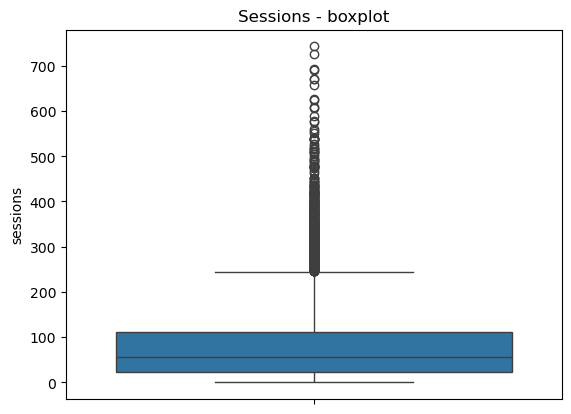

In [31]:
# Box plot
sns.boxplot(df['sessions'])
plt.title('Sessions - boxplot')


Text(0.5, 1.0, 'Sessions - histogram')

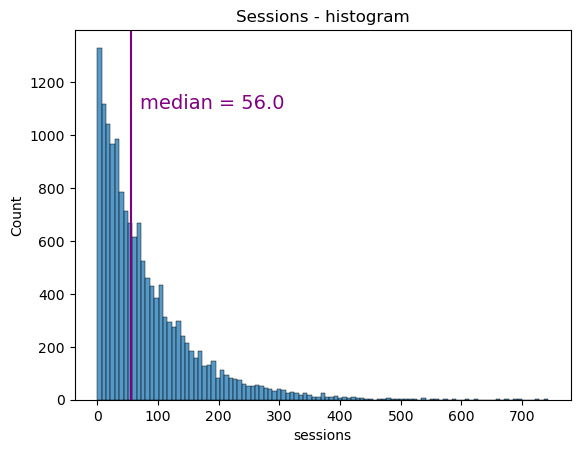

In [36]:
# Histogram
sns.histplot(df['sessions'])
median=df['sessions'].median(numeric_only=True)
plt.axvline(median, color='purple', label=median)
plt.text(70, 1100, f'median = {median}', color='purple', fontsize = 14)
plt.title('Sessions - histogram')

The `sessions` variable is a right-skewed distribution with half of the observations having 56 or fewer sessions. However, as indicated by the boxplot, some users have more than 700.


**`drives`**

An occurrence of driving at least 1 km during the month


Text(0.5, 1.0, 'Drives - boxplot')

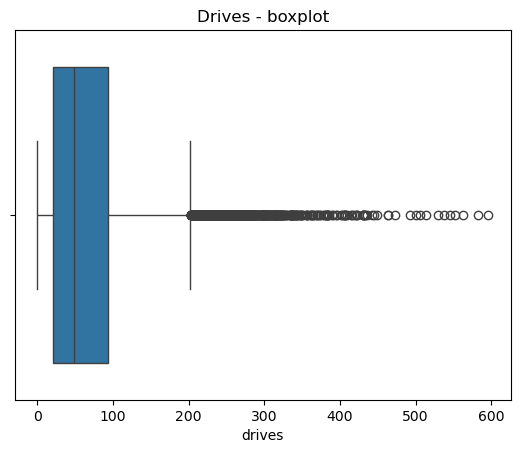

In [38]:
# Box plot
sns.boxplot(x=df['drives'])
plt.title('Drives - boxplot')

Text(0.5, 1.0, 'Drives - histogram')

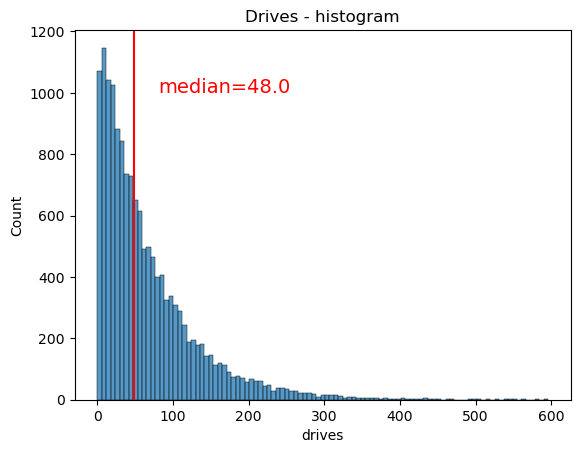

In [40]:
# Histogram
sns.histplot(df['drives'])
median=df['drives'].median()
plt.axvline(median, color='red', label=median)
plt.text(80,1000,f'median={median}',color='red', fontsize=14)
plt.title('Drives - histogram')

The `drives` information follows a distribution similar to the `sessions` variable. It is right-skewed, approximately log-normal, with a median of 48. However, some drivers had over 400 drives in the last month.


**`total_sessions`**
 
A model estimate of the total number of sessions since a user has onboarded

Text(0.5, 1.0, 'Total_sessions - boxplot')

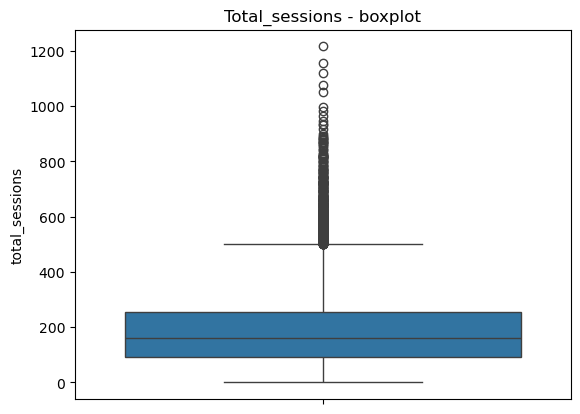

In [41]:
# Box plot
sns.boxplot(df['total_sessions'])
plt.title('Total_sessions - boxplot')

Text(0.5, 1.0, 'Total_sessions - histogram')

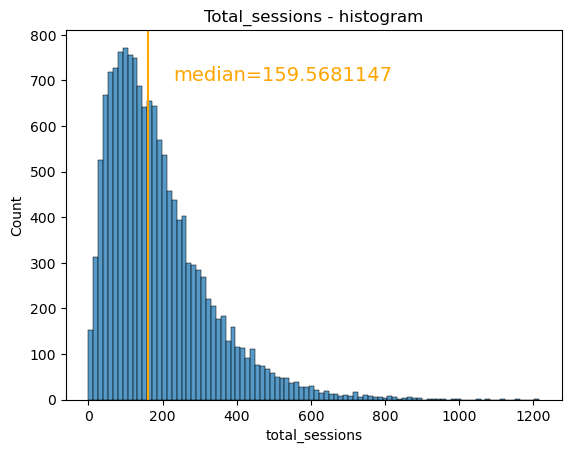

In [43]:
# Histogram
sns.histplot(df['total_sessions'])
median=df['total_sessions'].median()
plt.axvline(median,color='orange')
plt.text(230,700,f'median={median}',color='orange',fontsize=14)
plt.title('Total_sessions - histogram')

The `total_sessions` is a right-skewed distribution. The median total number of sessions is 159.6. This is interesting information because, if the median number of sessions in the last month was 48 and the median total sessions was ~160, then it seems that a large proportion of a user's total drives might have taken place in the last month. This is something you can examine more closely later.

**`n_days_after_onboarding`**

The number of days since a user signed up for the app

Text(0.5, 1.0, 'n_days_after_onboarding - box plot')

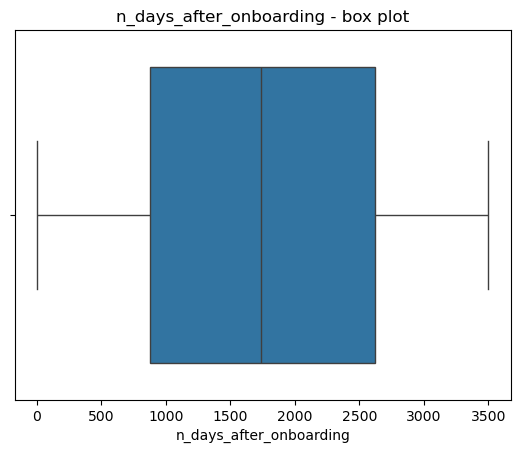

In [45]:
# Box plot
sns.boxplot(x=df['n_days_after_onboarding'])
plt.title('n_days_after_onboarding - box plot')

Text(0.5, 1.0, 'n_days_after_onboarding - histogram')

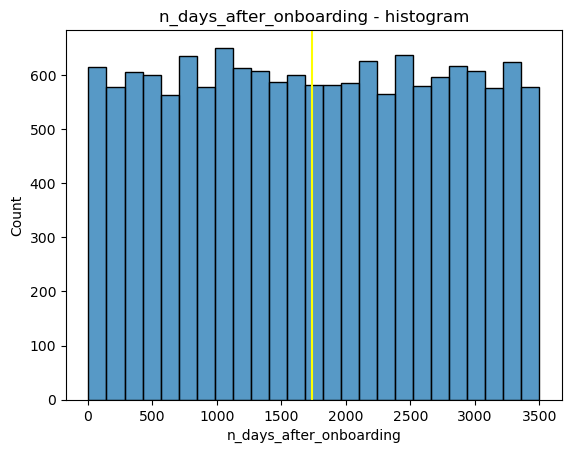

In [47]:
# Histogram
sns.histplot(df['n_days_after_onboarding'])
median=df['n_days_after_onboarding'].median()
plt.axvline(median,color='yellow')
plt.title('n_days_after_onboarding - histogram')

The total user tenure (i.e., number of days since onboarding) is a uniform distribution with values ranging from near-zero to \~3,500 (\~9.5 years).

**`driven_km_drives`**

Total kilometers driven during the month

Text(0.5, 1.0, 'driven_km_drives - box plot')

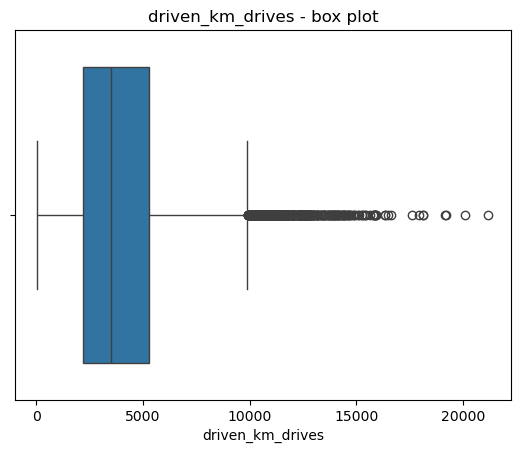

In [49]:
# Box plot
sns.boxplot(x=df['driven_km_drives'])
plt.title('driven_km_drives - box plot')

Text(0.5, 1.0, 'driven_km_drives - histogram')

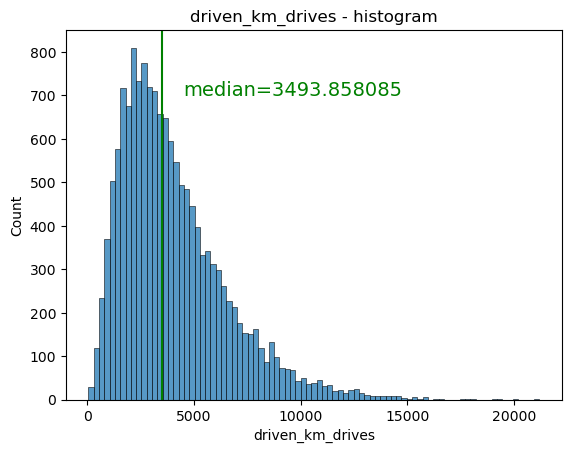

In [55]:
# Histogram
sns.histplot(df['driven_km_drives'])
median=df['driven_km_drives'].median()
plt.axvline(median,color='green', label=median)
plt.text(4500,700,f'median={median}',color='green', fontsize=14)
plt.title('driven_km_drives - histogram')

The number of drives driven in the last month per user is a right-skewed distribution with half the users driving under 3,495 kilometers. As you discovered in the analysis from the previous course, the users in this dataset drive _a lot_. The longest distance driven in the month was over half the circumferene of the earth.

**`duration_minutes_drives`**

Total duration driven in minutes during the month

Text(0.5, 1.0, 'duration_minutes_drives - box plot')

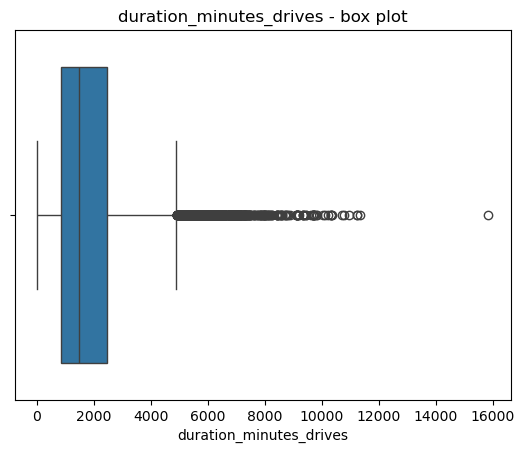

In [54]:
# Box plot
sns.boxplot(x=df['duration_minutes_drives'])
plt.title('duration_minutes_drives - box plot')

Text(0.5, 1.0, 'duration_minutes_drives - histogram')

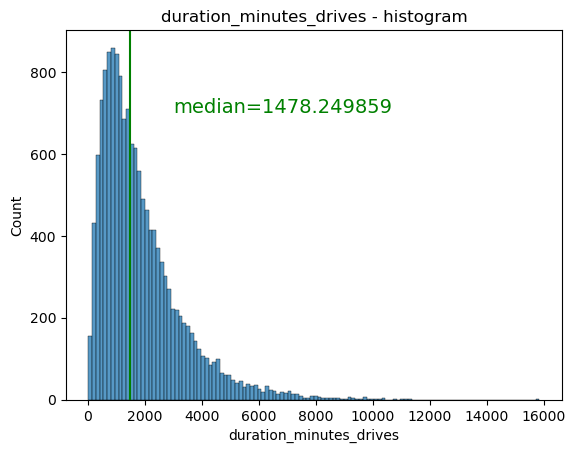

In [60]:
# Histogram
sns.histplot(df['duration_minutes_drives'])
median=df['duration_minutes_drives'].median()
plt.axvline(median,color='green', label=median)
plt.text(3000,700,f'median={median}',color='green', fontsize=14)
plt.title('duration_minutes_drives - histogram')

The `duration_minutes_drives` variable has a heavily skewed right tail. Half of the users drove less than \~1,478 minutes (\~25 hours), but some users clocked over 250 hours over the month.

**`activity_days`**

Number of days the user opens the app during the month

Text(0.5, 1.0, 'activity_days - box plot')

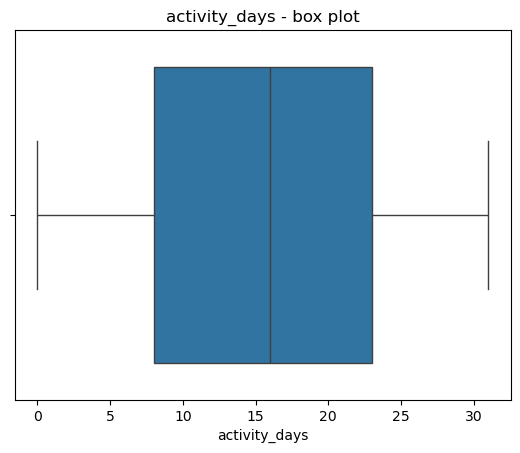

In [61]:
# Box plot
sns.boxplot(x=df['activity_days'])
plt.title('activity_days - box plot')

Text(0.5, 1.0, 'activity_days - histogram')

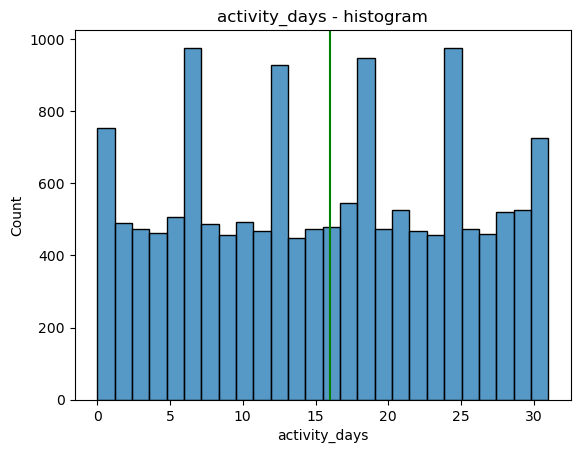

In [63]:
# Histogram
sns.histplot(df['activity_days'])
median=df['activity_days'].median()
plt.axvline(median,color='green', label=median)
plt.title('activity_days - histogram')

Within the last month, users opened the app a median of 16 times. The box plot reveals a centered distribution. The histogram shows a nearly uniform distribution of ~500 people opening the app on each count of days. However, there are ~250 people who didn't open the app at all and ~250 people who opened the app every day of the month.
 
This distribution is noteworthy because it does not mirror the `sessions` distribution, which you might think would be closely correlated with `activity_days`.


**`driving_days`**
 
Number of days the user drives (at least 1 km) during the month

Text(0.5, 1.0, 'driving_days - box plot')

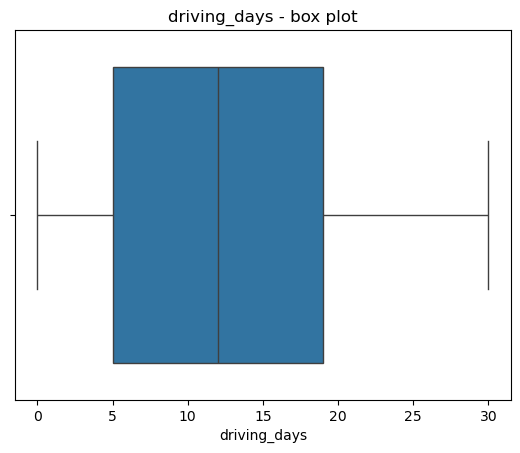

In [64]:
# Box plot
sns.boxplot(x=df['driving_days'])
plt.title('driving_days - box plot')

Text(0.5, 1.0, 'driving_days - histogram')

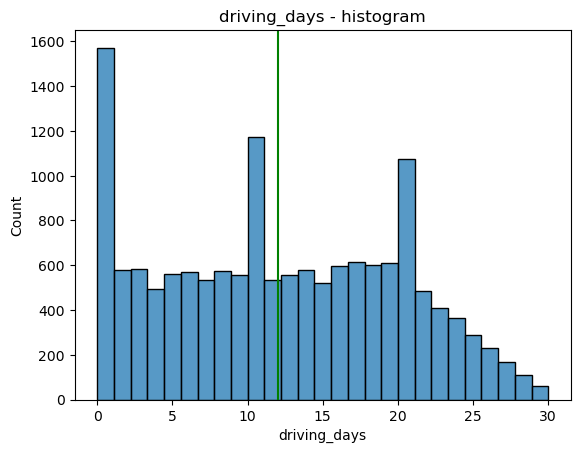

In [65]:
# Histogram
sns.histplot(df['driving_days'])
median=df['driving_days'].median()
plt.axvline(median,color='green', label=median)
plt.title('driving_days - histogram')

The number of days users drove each month is almost uniform, and it largely correlates with the number of days they opened the app that month, except the `driving_days` distribution tails off on the right.
 
However, there were almost twice as many users (\~1,000 vs. \~550) who did not drive at all during the month. This might seem counterintuitive when considered together with the information from `activity_days`. That variable had \~500 users opening the app on each of most of the day counts, but there were only \~250 users who did not open the app at all during the month and ~250 users who opened the app every day. Flag this for further investigation later.

**`device`**
 
The type of device a user starts a session with

This is a categorical variable, so you do not plot a box plot for it. A good plot for a binary categorical variable is a pie chart.

Text(0.5, 1.0, 'Device - pie chart')

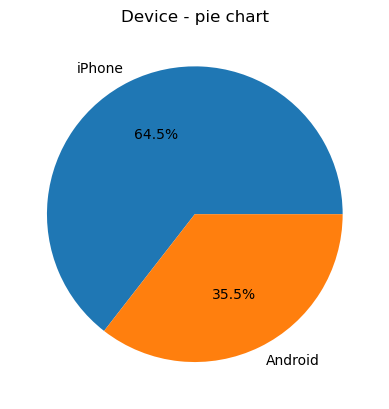

In [67]:
# Pie chart
device=df['device'].value_counts()
plt.pie(device,labels=device.index, autopct='%1.1f%%')
plt.title('Device - pie chart')

There are nearly twice as many iPhone users as Android users represented in this data.

**`label`**

Binary target variable (“retained” vs “churned”) for if a user has churned anytime during the course of the month

This is also a categorical variable, and as such would not be plotted as a box plot. Plot a pie chart instead.

Text(0.5, 1.0, 'Label - pie chart')

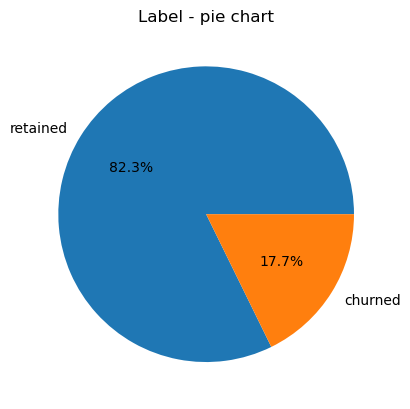

In [68]:
# Pie chart
label=df['label'].value_counts()
plt.pie(label,labels=label.index,autopct='%1.1f%%')
plt.title('Label - pie chart')

Less than 18% of the users churned.

**`driving_days` vs. `activity_days`**

Because both `driving_days` and `activity_days` represent counts of days over a month and they're also closely related, you can plot them together on a single histogram. This will help to better understand how they relate to each other without having to scroll back and forth comparing histograms in two different places.

Now, I plot a histogram that, for each day, has a bar representing the counts of `driving_days` and `activity_days`.

Text(0.5, 1.0, 'driving days vs activity days - histogram')

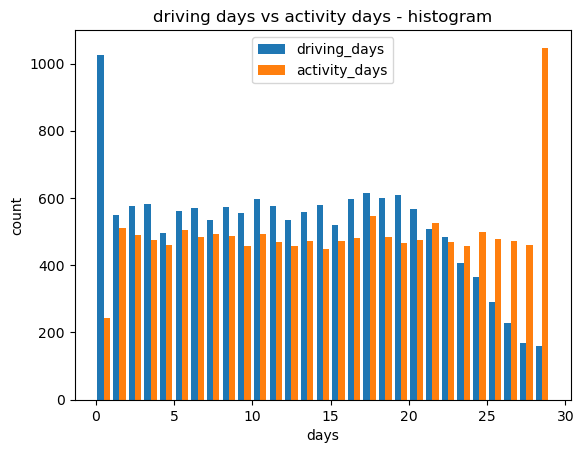

In [74]:
# Histogram
plt.hist([df['driving_days'],df['activity_days']],
         label=['driving_days','activity_days'], bins=range(0,30))
plt.xlabel('days')
plt.ylabel('count')
plt.legend()
plt.title('driving days vs activity days - histogram')


As observed previously, this might seem counterintuitive. After all, why are there _fewer_ people who didn't use the app at all during the month and _more_ people who didn't drive at all during the month?

On the other hand, it could just be illustrative of the fact that, while these variables are related to each other, they're not the same. People probably just open the app more than they use the app to drive&mdash;perhaps to check drive times or route information, to update settings, or even just by mistake.

Nonetheless, it might be worthwile to contact the data team at Waze to get more information about this, especially because it seems that the number of days in the month is not the same between variables.

Confirm the maximum number of days for each variable&mdash;`driving_days` and `activity_days`.

In [75]:

print('Driving days max = ',df['driving_days'].max())
print('Driving days max = ',df['activity_days'].max())

Driving days max =  30
Driving days max =  31


It's true. Although it's possible that not a single user drove all 31 days of the month, it's highly unlikely, considering there are 15,000 people represented in the dataset.
 
One other way to check the validity of these variables is to plot a simple scatter plot with the x-axis representing one variable and the y-axis representing the other.

Text(0.5, 1.0, 'driving_days vs. activity_days - scatter plot')

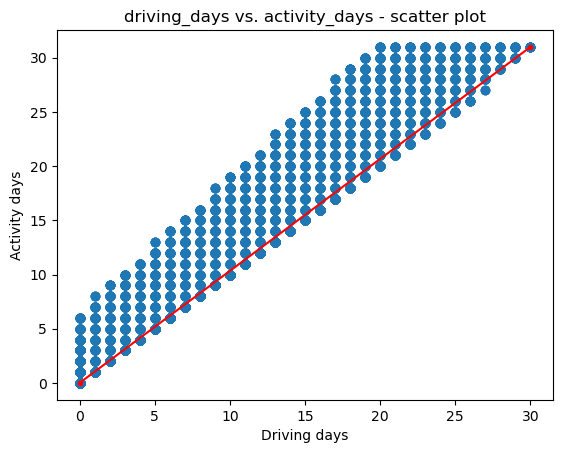

In [76]:
# Scatter plot
plt.scatter(df['driving_days'], df['activity_days'])
plt.xlabel('Driving days')
plt.ylabel('Activity days')
plt.plot([0,df['driving_days'].max()], [0,df['activity_days'].max()], '.r-')
plt.title("driving_days vs. activity_days - scatter plot")

Notice that there is a theoretical limit. If you use the app to drive, then by definition it must count as a day-use as well. In other words, you cannot have more drive-days than activity-days. None of the samples in this data violate this rule, which is good.

**Retention by device**
 
I plot a histogram that has four bars&mdash;one for each device-label combination&mdash;to show how many iPhone users were retained/churned and how many Android users were retained/churned.

Text(0.5, 1.0, 'Retention by device histogram')

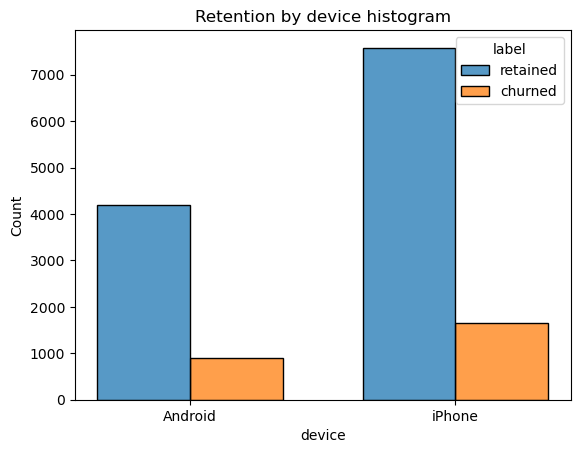

In [77]:
# Histogram
sns.histplot(x=df['device'], hue=df['label'], multiple='dodge', shrink=0.7)
plt.title("Retention by device histogram")

The proportion of churned users to retained users is consistent between device types.


**Retention by kilometers driven per driving day**
 
We discovered that the median distance driven per driving day last month for users who churned was 697.54 km, versus 289.55 km for people who did not churn. I examine this further.
 

In [78]:
# Create `km_per_driving_day` column
df["km_per_driving_day"] = df["driven_km_drives"] / df["driving_days"]

# Convert infinite values to zero
df.loc[df["km_per_driving_day"] == np.inf, "km_per_driving_day"] = 0

# Call `describe()` on the new column
df["km_per_driving_day"].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

The maximum value is 15,420 kilometers per drive day. This is physically impossible. Driving 100 km/hour for 12 hours is 1,200 km. It's unlikely many people averaged more than this each day they drove, so, for now, disregard rows where the distance in this column is greater than 1,200 km.

<Axes: xlabel='km_per_driving_day', ylabel='Count'>

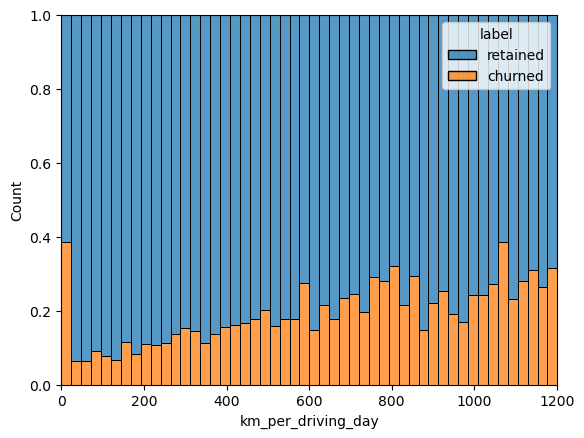

In [79]:
# Histogram
sns.histplot(x=df['km_per_driving_day'], hue=df['label'], 
             multiple='fill', bins=50, binrange=(0,1201))

The churn rate tends to increase as the mean daily distance driven increases, confirming what was found in the previous course. It would be worth investigating further the reasons for long-distance users to discontinue using the app.

**Churn rate per number of driving days**
 
Create another histogram just like the previous one, only this time it should represent the churn rate for each number of driving days.


<Axes: xlabel='driving_days', ylabel='Count'>

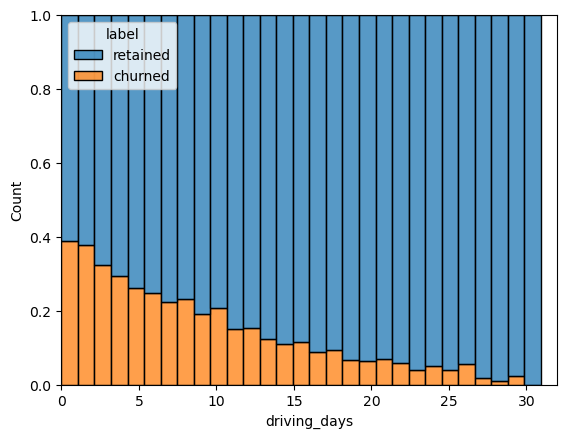

In [80]:
# Histogram
sns.histplot(x=df['driving_days'], hue=df['label'], 
             multiple='fill', bins=30, binrange=(0,32))

The churn rate is highest for people who didn't use Waze much during the last month. The more times they used the app, the less likely they were to churn. While 40% of the users who didn't use the app at all last month churned, nobody who used the app 30 days churned.

This isn't surprising. If people who used the app a lot churned, it would likely indicate dissatisfaction. When people who don't use the app churn, it might be the result of dissatisfaction in the past, or it might be indicative of a lesser need for a navigational app. Maybe they moved to a city with good public transportation and don't need to drive anymore.

**Proportion of sessions that occurred in the last month**

Create a new column `percent_sessions_in_last_month` that represents the percentage of each user's total sessions that were logged in their last month of use.

In [ ]:
df['percent_sessions_in_last_month']=round(df['sessions']/df['total_sessions']*100,2)

# The median value of the new column
df['percent_sessions_in_last_month'].median()

42.31

Text(0.5, 1.0, 'percent_sessions_in_last_month - histogram')

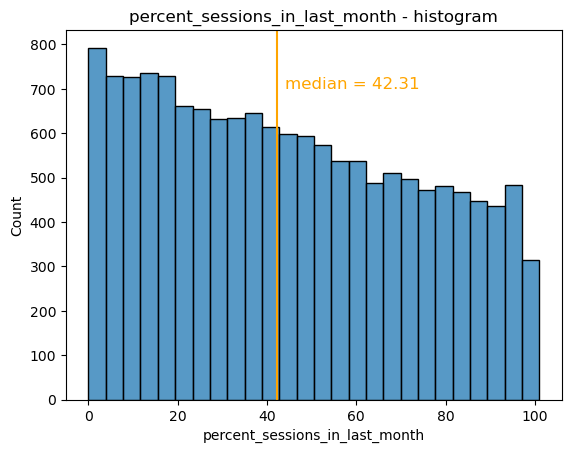

In [83]:
# Histogram depicting the distribution of values in this new column
sns.histplot(df['percent_sessions_in_last_month'], binrange=(0,101))
median=df['percent_sessions_in_last_month'].median()
plt.axvline(median,color='orange')
plt.text(44, 700, f"median = {median}", color="orange", fontsize = 12)
plt.title("percent_sessions_in_last_month - histogram")

Half of the people in the dataset had 40% or more of their sessions in just the last month, yet the overall median time since onboarding is almost five years.

Now, I make a histogram of `n_days_after_onboarding` for just the people who had 40% or more of their total sessions in the last month.

Text(0.5, 1.0, 'n_days_after_onboarding for users >= 40% sessions on last month - histogram')

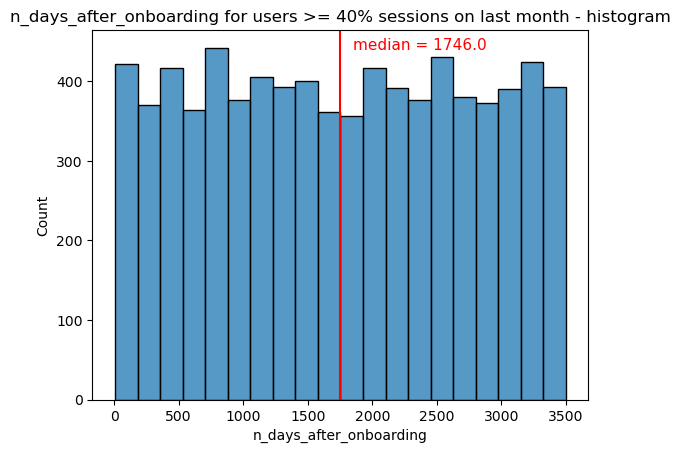

In [85]:
y = df[df["percent_sessions_in_last_month"] >= 40]
sns.histplot(y['n_days_after_onboarding'])
median=y['n_days_after_onboarding'].median()
plt.axvline(median,color='red')
plt.text(1850, 440, f"median = {median}", color="red", fontsize = 11)
plt.title("n_days_after_onboarding for users >= 40% sessions on last month - histogram")


The number of days since onboarding for users with 40% or more of their total sessions occurring in just the last month is a uniform distribution. This is very strange. It's worth asking Waze why so many long-time users suddenly used the app so much in the last month.

**Handling outliers**

The box plots from the previous section indicated that many of these variables have outliers. These outliers do not seem to be data entry errors; they are present because of the right-skewed distributions.
 
Depending on what I'll decide to do with this data, it may be useful to impute outlying data with more reasonable values. One way of performing this imputation is to set a threshold based on a percentile of the distribution.

To practice this technique, I write a function that calculates the 95th percentile of a given column, then imputes values > the 95th percentile with the value at the 95th percentile.  such as the 95th percentile of the distribution.

In [86]:
def outlier_handler(column_name, percentile):
    # Calculate threshold
    threshold = df[column_name].quantile(percentile)
    # Impute threshold for values > than threshold
    df.loc[df[column_name] > threshold, column_name] = threshold

    print('{:>25} | percentile: {} | threshold: {}'.format(column_name, percentile, threshold))

Next, apply that function to the following columns:
* `sessions`
* `drives`
* `total_sessions`
* `driven_km_drives`
* `duration_minutes_drives`

In [88]:
outlier_handler('sessions',0.95)
outlier_handler('drives',0.95)
outlier_handler('total_sessions',0.95)
outlier_handler('driven_km_drives',0.95)
outlier_handler('duration_minutes_drives',0.95)

                 sessions | percentile: 0.95 | threshold: 243.0
                   drives | percentile: 0.95 | threshold: 201.0
           total_sessions | percentile: 0.95 | threshold: 454.3632037399997
         driven_km_drives | percentile: 0.95 | threshold: 8889.7942356
  duration_minutes_drives | percentile: 0.95 | threshold: 4668.899348999998


**Conclusion**
 
Analysis revealed that the overall churn rate is \~17%, and that this rate is consistent between iPhone users and Android users.
 
Perhaps you feel that the more deeply you explore the data, the more questions arise. This is not uncommon! In this case, it's worth asking the Waze data team why so many users used the app so much in just the last month.
 
Also, EDA has revealed that users who drive very long distances on their driving days are _more_ likely to churn, but users who drive more often are _less_ likely to churn. The reason for this discrepancy is an opportunity for further investigation, and it would be something else to ask the Waze data team about.

1. What types of distributions did you notice in the variables? What did this tell you about the data?

There are different types of distributions such as uniform, centered distributio and right-skewed distribution.

2. Was there anything that led you to believe the data was erroneous or problematic in any way? 

The missing data from label column, the big driven distances and the huge part of sessions and drives from the last month. The last one is related to the additional EDA that I realised and found 1761 rows of clients that drove in medium more than 300kms/hour wich is questionable.

3. Did your investigation give rise to further questions that you would like to explore or ask the Waze team about?

Why so many long-time users suddenly used the app so much in the last month.

4. What percentage of users churned and what percentage were retained?

Analysis revealed that the overall churn rate is ~17%, and that this rate is consistent between iPhone users and Android users.

5. What factors correlated with user churn? How?

The churn rate tends to increase as the mean daily distance driven increases. It would be worth investigating further the reasons for long-distance users to discontinue using the app.

6. Did newer uses have greater representation in this dataset than users with longer tenure? How do you know?

The total user tenure (i.e., number of days since onboarding) is a uniform distribution with values ranging from near-zero to ~ 3.500 (~ 9,5 years).

### 3. Hypothesis testing

My goal is to conduct a two-sample t-test. Recall the steps for conducting a hypothesis test:

1. State the null hypothesis and the alternative hypothesis
2. Choose a signficance level
3. Find the p-value
4. Reject or fail to reject the null hypothesis

**Note:** This is a t-test for two independent samples. This is the appropriate test since the two groups are independent (Android users vs. iPhone users).

**The purpose** of this project is to demostrate knowledge of how to conduct a two-sample hypothesis test.

**The goal** is to apply descriptive statistics and hypothesis testing in Python.

In order to perform this analysis, you must turn each label into an integer. The following code assigns a `1` for an `iPhone` user and a `2` for `Android`. It assigns this label back to the variable `device_new`.

Create a dictionary called `map_dictionary` that contains the class labels (`'Android'` and `'iPhone'`) for keys and the values you want to convert them to (`2` and `1`) as values.

Create a new column called `device_type` that is a copy of the device column.

Use the `map()` method on the `device_type` series. Pass map_dictionary as its argument. Reassign the result back to the device_type series.

In [89]:
# 1. Create `map_dictionary`
map_dictionary={
    'iPhone':1,
    'Android':2
               }

# 2. Create new `device_type` column and map the new column to the dictionary
df['device_type']=df['device'].map(map_dictionary)

We are interested in the relationship between device type and the number of drives. One approach is to look at the average number of drives for each device type. I calculate these averages.


In [90]:
df.groupby('device_type')['drives'].mean()


device_type
1    64.446340
2    63.353482
Name: drives, dtype: float64

Based on the averages shown, it appears that drivers who use an iPhone device to interact with the application have a higher number of drives on average. However, this difference might arise from random sampling, rather than being a true difference in the number of drives. To assess whether the difference is statistically significant, we conduct a hypothesis test.

Recall the difference between the null hypothesis ($H_0$) and the alternative hypothesis ($H_1$).

$H_0$: iPhone users and Android users have the same mean drives.
 
$H_1$: iPhone users and Android users do not have the same mean drives.

In [91]:
significance_level=0.05
# 1. Isolate the `drives` column for iPhone users.
df_drives_iphone = df.loc[df['device_type']==1,'drives']

# 2. Isolate the `drives` column for Android users.
df_drives_android = df.loc[df['device_type']==2,'drives']

# 3. Perform the t-test
stats.ttest_ind(a=df_drives_iphone,b=df_drives_android,equal_var=False)

TtestResult(statistic=np.float64(1.1643714136026293), pvalue=np.float64(0.24429844267242226), df=np.float64(11148.669519764011))

Based on the p_value which is 14,33% and it is higher than our significance level of 5 %, I fail to reject the null hypothesis which means that there is no difference in the amount of drives between drivers using iPhone or Android device.


### 4. Regression Analysis

Now, I will build a binomial logistic regression model. 

The **purpose** of this project is to demostrate knowledge of exploratory data analysis (EDA) and a binomial logistic regression model.

The **goal** is to build a binomial logistic regression model and evaluate the model's performance.

First, we use `.drop()` to remove the ID column since we don't need this information for the analysis.

In [137]:
df=df.drop(['ID'],axis=1)

KeyError: "['ID'] not found in axis"

**`professional_driver`**
 
Create a new, binary feature called `professional_driver` that is a 1 for users who had 60 or more drives <u>**and**</u> drove on 15+ days in the last month.
 
The objective is to create a new feature that separates professional drivers from other drivers.

In [ ]:
# Create `professional_driver` column
df['professional_driver']=np.where( (df['drives']>=60) & (df['driving_days']>=15) , 1, 0)
df.head()

,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_drive,km_per_driving_day,drives_per_driving_day,percent_sessions_in_last_month,device_type,professional_driver
0,retained,243,201,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,11.632058,138.360267,11.894737,95.37,2,1
1,retained,133,107,326.896596,1225,19,64,8889.794236,3160.472914,13,11,iPhone,128.186173,1246.901868,9.727273,40.69,1,0
2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,32.201567,382.393602,11.875000,84.12,2,0
3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,22.839778,304.530374,13.333333,72.50,1,0
4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,58.091206,219.455667,3.777778,49.93,2,1


Now, I perform a quick inspection of the new variable.

1. Check the count of professional drivers and non-professionals
 
2. Within each class (professional and non-professional) calculate the churn rate

In [ ]:
# 1. Check count of professionals and non-professionals
print(df['professional_driver'].value_counts())

# 2. Check in-class churn rate
df.groupby('professional_driver')['label'].value_counts(normalize=True)

professional_driver
0    12405
1     2594
Name: count, dtype: int64


professional_driver  label   
0                    retained    0.801202
                     churned     0.198798
1                    retained    0.924437
                     churned     0.075563
Name: proportion, dtype: float64

The churn rate for professional drivers is 7.6%, while the churn rate for non-professionals is 19.9%. This seems like it could add predictive signal to the model.

Because we know from previous EDA that there is no evidence of a non-random cause of the 700 missing values in the `label` column, and because these observations comprise less than 5% of the data, we use the `dropna()` method to drop the rows that are missing this data.

In [ ]:
# Drop rows with missing data in `label` column
df=df.dropna(subset=['label'])

**Impute outliers**

Previously, we determined that seven of the variables had clear signs of containing outliers:

- `sessions`
- `drives`
- `total_sessions`
- `total_navigations_fav1`
- `total_navigations_fav2`
- `driven_km_drives`
- `duration_minutes_drives`

For this analysis, we impute the outlying values for these columns, calculate the 95th percentile of each column and change to this value any value in the column that exceeds it.

In [ ]:
# Impute outliers
columns = ["sessions", "drives", "total_sessions", "total_navigations_fav1", "total_navigations_fav2",
           "driven_km_drives", "duration_minutes_drives"]
for i in columns:
    limit=df[i].quantile(0.95)
    df.loc[df[i]>limit, i]=limit

**Encode categorical variables**

We change the data type of the `label` column to be binary. This change is needed to train a logistic regression model.
 
Assign a `0` for all `retained` users.
 
Assign a `1` for all `churned` users.
 
Save this variable as `label2` as to not overwrite the original `label` variable.

In [ ]:
# Create binary `label2` column
df['label2']=np.where(df['label']=='retained',0,1)

**Determine whether assumptions have been met**

The following are the assumptions for logistic regression:
 
* Independent observations (This refers to how the data was collected.)
 
* No extreme outliers
 
* Little to no multicollinearity among X predictors
 
* Linear relationship between X and the **logit** of y
 
For the first assumption, we can assume that observations are independent for this project.
 
The second assumption has already been addressed.
 
The last assumption will be verified after modeling.
 
**Note:** In practice, modeling assumptions are often violated, and depending on the specifics of the use case and the severity of the violation, it might not affect the model much at all or it will result in a failed model.

**Collinearity**
 
We check the correlation among predictor variables. First, we generate a correlation matrix.

In [ ]:
df_corr = df.drop(["label", "device"], axis = 1)
df_corr.corr()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_drive,km_per_driving_day,drives_per_driving_day,percent_sessions_in_last_month,device_type,professional_driver,label2
sessions,1.000000,0.996942,0.597299,0.007101,0.001858,0.008536,0.002995,-0.004545,0.025113,0.020294,-0.321676,-0.011569,0.454513,0.614136,-0.012704,0.443654,0.034911
drives,0.996942,1.000000,0.595396,0.006940,0.001058,0.009505,0.003445,-0.003889,0.024357,0.019608,-0.325440,-0.010989,0.455807,0.614282,-0.011684,0.444425,0.035865
total_sessions,0.597299,0.595396,1.000000,0.006615,0.000194,0.010363,0.001015,-0.000345,0.015757,0.012957,-0.194402,-0.016162,0.274758,-0.113455,-0.012133,0.254532,0.024568
n_days_after_onboarding,0.007101,0.006940,0.006615,1.000000,-0.002450,-0.004968,-0.004655,-0.010167,-0.009418,-0.007321,0.004168,0.011764,-0.002340,-0.000874,0.011299,0.003770,-0.129263
total_navigations_fav1,0.001858,0.001058,0.000194,-0.002450,1.000000,0.002866,-0.007365,0.005646,0.010902,0.010419,-0.005254,-0.000197,0.009056,0.015181,0.001316,-0.000224,0.052322
total_navigations_fav2,0.008536,0.009505,0.010363,-0.004968,0.002866,1.000000,0.003567,-0.003009,-0.004425,0.002000,0.002902,0.006751,0.002379,0.000604,0.000275,0.007126,0.015032
driven_km_drives,0.002995,0.003445,0.001015,-0.004655,-0.007365,0.003567,1.000000,0.690547,-0.007445,-0.009550,0.227341,0.344765,0.013289,-0.002087,0.002086,-0.000901,0.019771
duration_minutes_drives,-0.004545,-0.003889,-0.000345,-0.010167,0.005646,-0.003009,0.690547,1.000000,-0.007895,-0.009425,0.170689,0.239627,0.003930,-0.007882,0.007709,-0.012128,0.040407
activity_days,0.025113,0.024357,0.015757,-0.009418,0.010902,-0.004425,-0.007445,-0.007895,1.000000,0.947687,-0.005588,-0.397433,-0.413663,0.017840,0.010221,0.453825,-0.303851
driving_days,0.020294,0.019608,0.012957,-0.007321,0.010419,0.002000,-0.009550,-0.009425,0.947687,1.000000,-0.004337,-0.407917,-0.428643,0.013550,0.003859,0.469776,-0.294259


Text(0.5, 1.0, 'Correlation heatmap')

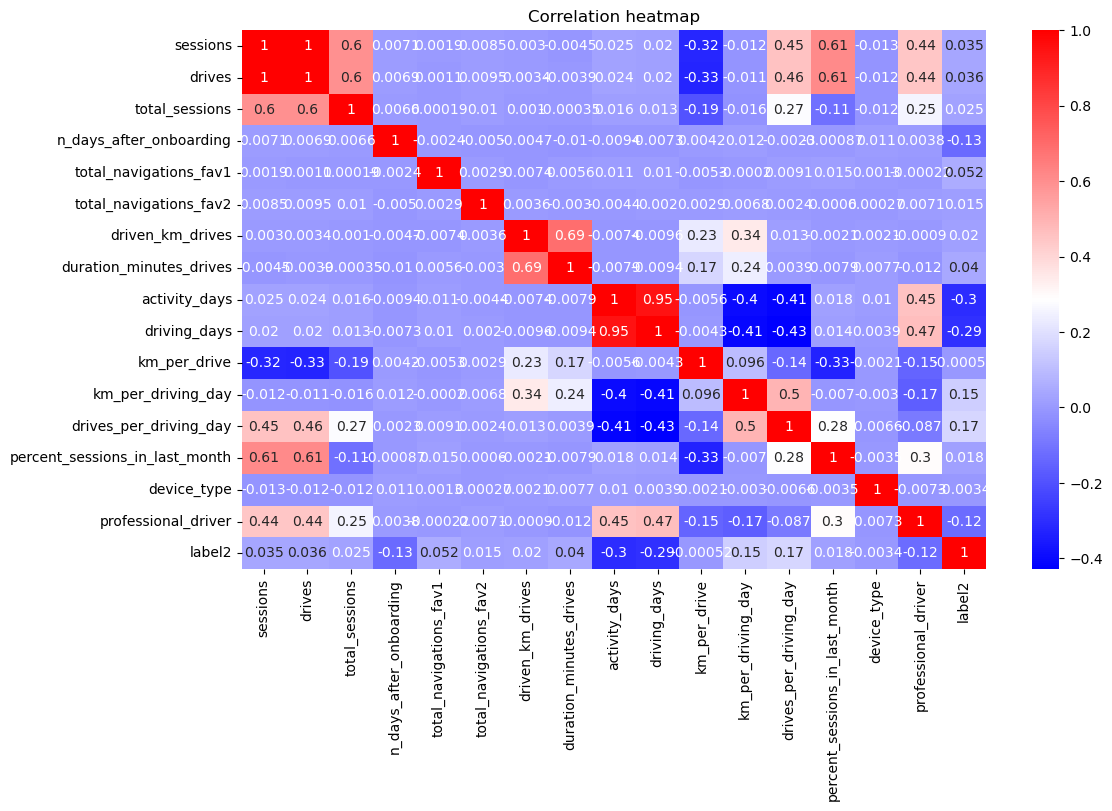

In [ ]:
# Plot correlation heatmap
plt.figure(figsize=(12,7))
sns.heatmap(df_corr.corr(method="pearson"), annot = True,  cmap="bwr")
plt.title('Correlation heatmap')


If there are predictor variables that have a Pearson correlation coefficient value greater than the **absolute value of 0.7**, these variables are strongly multicollinear. Therefore, only one of these variables should be used in the model.

Variables with high collinearity:

- Sessions and drives: collinearity 1.
- Activity days and driving days: collinearity 0.95

**Create dummies (if necessary)**

We have selected `device` as an X variable, so we need to create dummy variables since this variable is categorical.

**Note:** Variables with many categories should only be dummied if absolutely necessary. Each category will result in a coefficient for the model which can lead to overfitting.
 
Because this dataset only has one remaining categorical feature (`device`), it's not necessary to use one of these special functions. We can just implement the transformation directly.

We create a new, binary column called `device2` that encodes user devices as follows:
 
* `Android` -> `0`
* `iPhone` -> `1`

In [ ]:
# Create new `device2` variable
df['device2']=np.where(df['device']=='Android',0,1)

**Model building**

*Assign predictor variables and target*
 
To build the model we need to determine what X variables we want to include in the model to predict the target&mdash;`label2`.
 
Drop the following variables and assign the results to `X`:
 
* `label` (this is the target)
* `label2` (this is the target)
* `device` (this is the non-binary-encoded categorical variable)
* `sessions` (this had high multicollinearity)
* `driving_days` (this had high multicollinearity)
 
**Note:** Notice that `sessions` and `driving_days` were selected to be dropped, rather than `drives` and `activity_days`. The reason for this is that the features that were kept for modeling had slightly stronger correlations with the target variable than the features that were dropped.


In [143]:
# Isolate predictor variables
X = df.drop(columns = ["label", "label2","device", "sessions", "driving_days"])
original_columns = X.columns

# Isolate target variable
y=df['label2']

**Split the data**

**Note 1:** It is important to do a train test to obtain accurate predictions.  We always want to fit the model on the training set and evaluate the model on the test set to avoid data leakage.
 
**Note 2:** Because the target class is imbalanced (82% retained vs. 18% churned), we want to make sure that we don't get an unlucky split that over- or under-represents the frequency of the minority class. We set the function's `stratify` parameter to `y` to ensure that the minority class appears in both train and test sets in the same proportion that it does in the overall dataset.

In [144]:
# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify = y, random_state=24)

# We fill NAs and scale the features in order to not get errors in logistic regression
scaler=StandardScaler()

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_train = X_train .fillna(X_train.mean())
X_train = scaler.fit_transform(X_train)

X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_test = X_test.fillna(X_test.mean())
X_test = scaler.transform(X_test)

We se scikit-learn to instantiate a logistic regression model.

We fit the model on `X_train` and `y_train`.


In [145]:
model = LogisticRegression(penalty = None, max_iter= 350)
model.fit(X_train, y_train)

LogisticRegression(max_iter=350, penalty=None)

We call the `.coef_` attribute on the model to get the coefficients of each variable.  The coefficients are in order of how the variables are listed in the dataset.  Remember that the coefficients represent the change in the **log odds** of the target variable for **every one unit increase in X**.

In [146]:
model.coef_

array([[ 0.15429513,  0.03317256, -0.38801138,  0.14861431,  0.04169816,
        -0.09125593,  0.15380583, -0.89269993,  0.032869  ,  0.0498024 ,
        -0.03587624, -0.01336874, -0.00409075, -0.00426052,  0.00409075]])

In [147]:
# Call the model's `intercept_` attribute to get the intercept of the model.
model.intercept_

array([-1.83304385])

**Check final assumption**
 
Verify the linear relationship between X and the estimated log odds (known as logits) by making a regplot.
 
Call the model's `predict_proba()` method to generate the probability of response for each sample in the training data. (The training data is the argument to the method.) Assign the result to a variable called `training_probabilities`. This results in a 2-D array where each row represents a user in `X_train`. The first column is the probability of the user not churning, and the second column is the probability of the user churning.

In [148]:
# Get the predicted probabilities of the training data
training_probabilities=model.predict_proba(X_train)
training_probabilities

array([[0.77874945, 0.22125055],
       [0.94979263, 0.05020737],
       [0.9529072 , 0.0470928 ],
       ...,
       [0.83735539, 0.16264461],
       [0.83536835, 0.16463165],
       [0.64354727, 0.35645273]])

In logistic regression, the relationship between a predictor variable and the dependent variable does not need to be linear, however, the log-odds (a.k.a., logit) of the dependent variable with respect to the predictor variable should be linear. Here is the formula for calculating log-odds, where _p_ is the probability of response:
<br>
$$
logit(p) = ln(\frac{p}{1-p})
$$
<br>
 
1. Create a dataframe called `logit_data` that is a copy of `df`.
 
2. Create a new column called `logit` in the `logit_data` dataframe. The data in this column should represent the logit for each user.

In [149]:
# 1. Copy the `X_train` dataframe and assign to `logit_data`
logit_data = pd.DataFrame(X_train.copy(),  columns=original_columns)

# 2. Create a new `logit` column in the `logit_data` df
logit_data['logit']=[np.log(prob[1]/prob[0]) for prob in training_probabilities]

Now, we plot a regplot where the x-axis represents an independent variable and the y-axis represents the log-odds of the predicted probabilities.

In an exhaustive analysis, this would be plotted for each continuous or discrete predictor variable. Here we show only `driving_days`.

Text(0.5, 1.0, 'Activity_days log-odds plot')

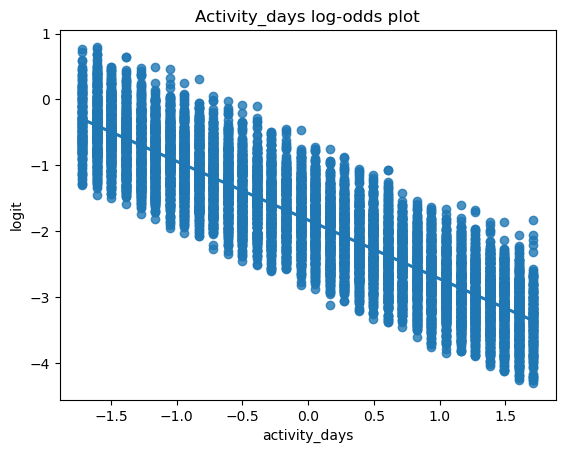

In [151]:
# Plot regplot of `activity_days` log-odds
sns.regplot(
    x='activity_days',
    y='logit',
    data=logit_data
)
plt.title("Activity_days log-odds plot")

**Results and evaluation**

If the logistic assumptions are met, the model results can be appropriately interpreted.

In [152]:
# Generate predictions on X_test
y_pred = model.predict(X_test)
print(y_pred)


[0 0 0 ... 0 0 0]


Now, use the `score()` method on the model with `X_test` and `y_test` as its two arguments. The default score in scikit-learn is **accuracy**.  


In [153]:
# Score the model (accuracy) on the test data
model.score(X_test,y_test)

0.8268531468531468

**Show results with a confusion matrix**

We use the `confusion_matrix` function to obtain a confusion matrix. Use `y_test` and `y_preds` as arguments.


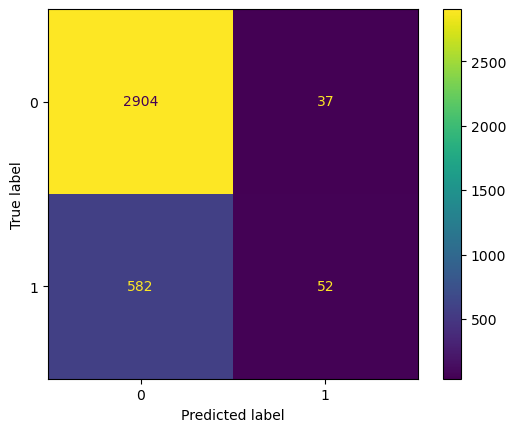

In [156]:
cm=metrics.confusion_matrix(y_test,y_pred, labels = model.classes_)
disp=metrics.ConfusionMatrixDisplay(cm, display_labels=model.classes_)
disp.plot()


In [157]:
# Calculate precision manually
print("Precision:", "%.6f" % (cm[1,1] / (cm[1,1] + cm[0,1])))

# Calculate recall manually
print("Recall:", "%.6f" % (cm[1,1] / (cm[1,1] + cm[1,0])))

# Create a classification report
print(classification_report(y_test, y_pred, target_names = ["Retained", "Churned"]))

Precision: 0.584270
Recall: 0.082019
              precision    recall  f1-score   support

    Retained       0.83      0.99      0.90      2941
     Churned       0.58      0.08      0.14       634

    accuracy                           0.83      3575
   macro avg       0.71      0.53      0.52      3575
weighted avg       0.79      0.83      0.77      3575



The model has decent precision but very low recall, which means that it makes a lot of false negative predictions and fails to capture users who will churn.



We generate a bar graph of the model's coefficients for a visual representation of the importance of the model's features.

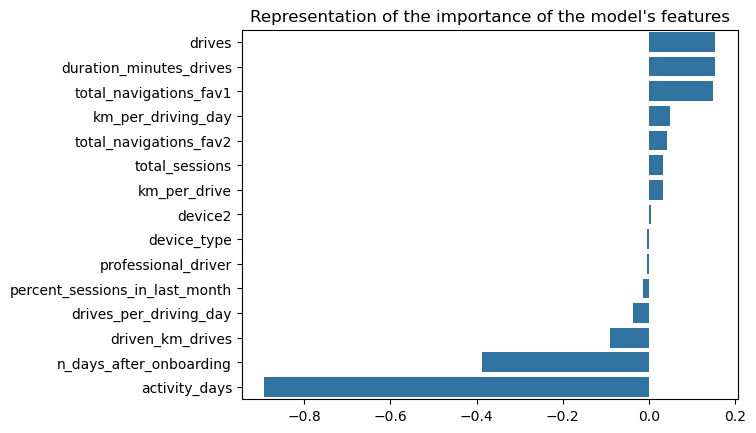

In [159]:
# Create a list of (column_name, coefficient) tuples
list_of_tuples = list(zip(original_columns, model.coef_[0]))

# Sort the list by coefficient value
list_of_tuples.sort(key=lambda x: x[1], reverse =True)

# Plot the feature importances
sns.barplot(x=[x[1] for x in list_of_tuples],
            y=[x[0] for x in list_of_tuples])
plt.title("Representation of the importance of the model's features")
plt.show()

### 5. Building a Machine Learning Model

Now, we will usie tree-based modeling techniques to predict on a binary target class.
<br/>

**The purpose** of this model is to find factors that drive user churn.

**The goal** of this model is to predict whether or not a Waze user is retained or churned.
<br/>

**Feature engineering**

`total_sessions_per_day`

Now, we create a new column that represents the mean number of sessions per day _since onboarding_.

In [175]:
# Create `total_sessions_per_day` feature
df['total_sessions_per_day']=df['total_sessions']/df['n_days_after_onboarding']

**`km_per_hour`**

Create a column representing the mean kilometers per hour driven in the last month.

In [176]:
# Create `km_per_hour` feature
df['km_per_hour'] = df['driven_km_drives'] / df['duration_minutes_drives']*60

**`percent_of_sessions_to_favorite`**

Finally, we create a new column that represents the percentage of total sessions that were used to navigate to one of the users' favorite places. Then, print descriptive statistics for the new column.

This is a proxy representation for the percent of overall drives that are to a favorite place. Since total drives since onboarding are not contained in this dataset, total sessions must serve as a reasonable approximation.

People whose drives to non-favorite places make up a higher percentage of their total drives might be less likely to churn, since they're making more drives to less familiar places.

In [177]:
# Create `percent_of_sessions_to_favorite` feature
df['percent_of_sessions_to_favorite']=(df['total_navigations_fav1']+df['total_navigations_fav2'])/df['total_sessions']
# Get descriptive stats
df['percent_of_sessions_to_favorite'].describe()

count    14299.000000
mean         1.575282
std          8.243636
min          0.000000
25%          0.212409
50%          0.648292
75%          1.593733
max        668.888397
Name: percent_of_sessions_to_favorite, dtype: float64

**Drop missing values**

Because we know from previous EDA that there is no evidence of a non-random cause of the 700 missing values in the `label` column, and because these observations comprise less than 5% of the data, we use the `dropna()` method to drop the rows that are missing this data.

In [178]:
# Drop rows with missing values
df=df.dropna(subset=['label'])

**Outliers**

We know from previous EDA that many of these columns have outliers. However, tree-based models are resilient to outliers, so there is no need to make any imputations.

**Variable encoding**

*Dummying features and target encoding*

We have already converted the variables into binary

*Feature selection*

Tree-based models can handle multicollinearity, so the only feature that can be cut is `ID`, since it doesn't contain any information relevant to churn.

*Evaluation metric*

Before modeling, we must decide on an evaluation metric. This will depend on the class balance of the target variable and the use case of the model.

First, we examine the class balance of the target variable.

In [179]:
df['label'].value_counts(normalize=True)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

Approximately 18% of the users in this dataset churned. This is an unbalanced dataset, but not extremely so. It can be modeled without any class rebalancing.

Now, consider which evaluation metric is best. Accuracy might not be the best gauge of performance because a model can have high accuracy on an imbalanced dataset and still fail to predict the minority class.

It was already determined that the risks involved in making a false positive prediction are minimal. No one stands to get hurt, lose money, or suffer any other significant consequence if they are predicted to churn. Therefore, we will select the model based on the recall score.

**Modeling workflow and model selection process**

The final modeling dataset contains 14,299 samples. This is towards the lower end of what might be considered sufficient to conduct a robust model selection process, but still doable.

1. Split the data into train/validation/test sets (60/20/20)

Note that, when deciding the split ratio and whether or not to use a validation set to select a champion model, consider both how many samples will be in each data partition, and how many examples of the minority class each would therefore contain. In this case, a 60/20/20 split would result in \~2,860 samples in the validation set and the same number in the test set, of which \~18%&mdash;or 515 samples&mdash;would represent users who churn.

2. Fit models and tune hyperparameters on the training set

3. Perform final model selection on the validation set

4. Assess the champion model's performance on the test set

**Split the data**

Now we're ready to model. The only remaining step is to split the data into features/target variable and training/validation/test sets.

1. Define a variable `X` that isolates the features. Remember not to use `device`.

2. Define a variable `y` that isolates the target variable (`label2`).

3. Split the data 80/20 into an interim training set and a test set. Don't forget to stratify the splits, and set the random state to 42.

4. Split the interim training set 75/25 into a training set and a validation set, yielding a final ratio of 60/20/20 for training/validation/test sets. Again, don't forget to stratify the splits and set the random state.

In [180]:
# 1. Isolate X variables
X = df.drop(columns=['label', 'label2', 'device'])

# 2. Isolate y variable
y=df['label2']

# 3. Split into train and test sets
X_tr,X_test,y_tr,y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 4. Split into train and validate sets
X_train,X_val,y_train,y_val = train_test_split(X_tr, y_tr, stratify=y_tr, test_size=0.25, random_state=42)


In [181]:
# Verify the number of samples in the partitioned data
for x in [X_train, X_val, X_test]:
    print(len(x))

8579
2860
2860


This aligns with expectations.

**Modeling**

*Random forest*

We begin with using `GridSearchCV` to tune a random forest model.

1. Instantiate the random forest classifier `rf` and set the random state.

2. Create a dictionary `cv_params` of any of the following hyperparameters and their corresponding values to tune. The more you tune, the better your model will fit the data, but the longer it will take.
 - `max_depth`
 - `max_features`
 - `max_samples`
 - `min_samples_leaf`
 - `min_samples_split`
 - `n_estimators`

3. Define a list `scoring` of scoring metrics for GridSearch to capture (precision, recall, F1 score, and accuracy).

4. Instantiate the `GridSearchCV` object `rf_cv`. Pass to it as arguments:
 - estimator=`rf`
 - param_grid=`cv_params`
 - scoring=`scoring`
 - cv: define the number of cross-validation folds you want (`cv=_`)
 - refit: indicate which evaluation metric you want to use to select the model (`refit=_`)

 `refit` should be set to `'recall'`.<font/>

In [182]:
# 1. Instantiate the random forest classifier
rf=RandomForestClassifier(random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params={'max_depth':[None],
           'max_features':[1.0],
           'max_samples':[1.0],
           'min_samples_leaf':[2],
           'min_samples_split':[2],
           'n_estimators':[300]
          }

# 3. Define a list of scoring metrics to capture
scoring=['accuracy','precision','recall','f1']

# 4. Instantiate the GridSearchCV object
rf_cv=GridSearchCV(rf,cv_params,scoring=scoring, cv=4, refit='recall')

Now we fit the model to the training data.

In [183]:
# 1. Replace infinites
X_train = np.where(np.isinf(X_train), np.nan, X_train)
X_test = np.where(np.isinf(X_test), np.nan, X_test)

# 2. Impute NaN
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

rf_cv.fit(X_train,y_train)

GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None], 'max_features': [1.0],
                         'max_samples': [1.0], 'min_samples_leaf': [2],
                         'min_samples_split': [2], 'n_estimators': [300]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

Examine the best average score across all the validation folds.

In [184]:
# Examine best score
rf_cv.best_score_

np.float64(0.11627814615278353)

Examine the best combination of hyperparameters.

In [185]:
# Examine best hyperparameter combo
rf_cv.best_params_

{'max_depth': None,
 'max_features': 1.0,
 'max_samples': 1.0,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

Now we use the `make_results()` function to output all of the scores of your model. Note that the function accepts three arguments.

In [186]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                   }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          },
                         )

    return table

In [187]:
# Pass the `GridSearch` object to the `make_results()` function.
make_results('RF_cv', rf_cv, 'recall')

,model,precision,recall,F1,accuracy
0,RF_cv,0.435995,0.116278,0.183574,0.816645


Asside from the accuracy, the scores aren't that good. However, recall that when you built the logistic regression model in the last course the recall was \~0.09, which means that this model has better recall and about the same accuracy, and it was trained on less data.

**XGBoost**

We try to improve your scores using an XGBoost model.

1. Instantiate the XGBoost classifier `xgb` and set `objective='binary:logistic'`. Also set the random state.

2. Create a dictionary `cv_params` of the following hyperparameters and their corresponding values to tune:
 - `max_depth`
 - `min_child_weight`
 - `learning_rate`
 - `n_estimators`

3. Define a list `scoring` of scoring metrics for grid search to capture (precision, recall, F1 score, and accuracy).

4. Instantiate the `GridSearchCV` object `xgb_cv`. Pass to it as arguments:
 - estimator=`xgb`
 - param_grid=`cv_params`
 - scoring=`scoring`
 - cv: define the number of cross-validation folds you want (`cv=_`)
 - refit: indicate which evaluation metric you want to use to select the model (`refit='recall'`)

In [188]:
# 1. Instantiate the XGBoost classifier
xgb=XGBClassifier(objective='binary:logistic', random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params={
    'max_depth':[6,12],
    'min_child_weight':[3,5],
    'learning_rate':[0.01,0.1],
    'n_estimators':[300]
}

# 3. Define a list of scoring metrics to capture
scoring=['accuracy','precision','recall','f1']

# 4. Instantiate the GridSearchCV object
xgb_cv=GridSearchCV(xgb,cv_params,scoring=scoring, cv=4, refit='recall')

Now, we fit the model to the `X_train` and `y_train` data.


In [189]:
xgb_cv.fit(X_train, y_train)

GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [6, 12],
                         'min_child_weight': [3, 5], 'n_estimators': [300]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

We get the best score from this model.

In [190]:
xgb_cv.best_score_

np.float64(0.16951236358613067)

And the best parameters.

In [191]:
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 12,
 'min_child_weight': 5,
 'n_estimators': 300}

Use the `make_results()` function to output all of the scores of your model. Note that the function accepts three arguments.

In [192]:
# Call 'make_results()' on the GridSearch object
make_results('XGB_cv',xgb_cv,'recall')

,model,precision,recall,F1,accuracy
0,XGB_cv,0.416131,0.169512,0.240535,0.810467


This model fit the data even better than the random forest model. The recall score is nearly double the recall score from the logistic regression model from the previous course, and it's almost 50% better than the random forest model's recall score, while maintaining a similar accuracy and precision score.

**Model selection**

Now, we use the best random forest model and the best XGBoost model to predict on the validation data. Whichever performs better will be selected as the champion model.

*Random forest*

In [194]:
X_val = np.where(np.isinf(X_val), np.nan, X_val)

# Use random forest model to predict on validation data
rf_val_preds=rf_cv.best_estimator_.predict(X_val)

We use the `get_test_scores()` function to generate a table of scores from the predictions on the validation data.

In [195]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy]
                          })

    return table

In [198]:
# Get validation scores for RF model
get_test_scores('RF_cv', rf_val_preds, y_val)

,model,precision,recall,F1,accuracy
0,RF_cv,0.438462,0.112426,0.178964,0.817133


Notice that the scores went down from the training scores across all metrics, but only by very little. This means that the model did not overfit the training data.

**XGBoost**

Now, do the same thing to get the performance scores of the XGBoost model on the validation data.

In [199]:
# Use XGBoost model to predict on validation data
xgb_pred_val = xgb_cv.best_estimator_.predict(X_val)

# Get validation scores for XGBoost model
get_test_scores("Validation XGBoost", xgb_pred_val, y_val)

,model,precision,recall,F1,accuracy
0,Validation XGBoost,0.393939,0.153846,0.221277,0.808042


Just like with the random forest model, the XGBoost model's validation scores were lower, but only very slightly. It is still the clear champion.

**Use champion model to predict on test data**

Now, use the champion model to predict on the test dataset. This is to give a final indication of how you should expect the model to perform on new future data, should you decide to use the model.

In [200]:
# Use XGBoost model to predict on test data
xgb_test_preds=xgb_cv.best_estimator_.predict(X_test)

# Get test scores for XGBoost model
get_test_scores('XGB test', xgb_test_preds, y_test)

,model,precision,recall,F1,accuracy
0,XGB test,0.436441,0.203156,0.277254,0.812238


The recall was exactly the same as it was on the validation data, but the precision declined notably, which caused all of the other scores to drop slightly. Nonetheless, this is stil within the acceptable range for performance discrepancy between validation and test scores.

**Confusion matrix**

Plot a confusion matrix of the champion model's predictions on the test data.

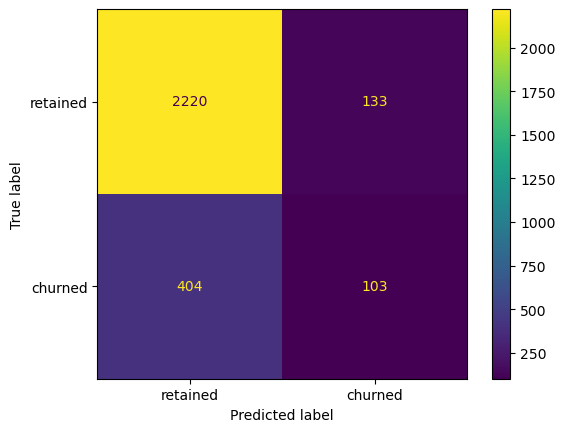

In [201]:
# Generate array of values for confusion matrix
cm=confusion_matrix(y_test, xgb_test_preds,labels=xgb_cv.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=['retained', 'churned'])
disp.plot();

The model predicted three times as many false negatives than it did false positives, and it correctly identified only 16.6% of the users who actually churned.

**Feature importance**

We use the `plot_importance` function to inspect the most important features of the final model.

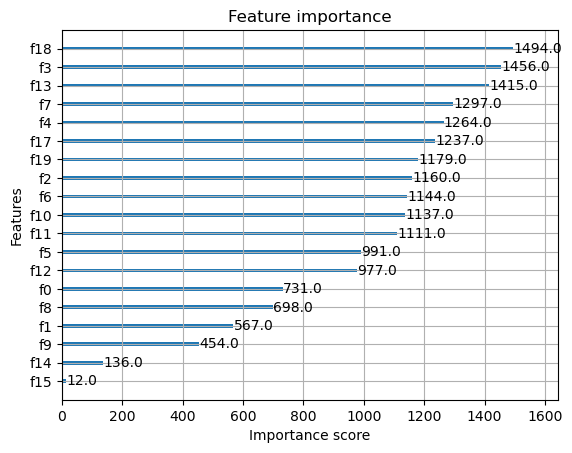

In [202]:
plot_importance(xgb_cv.best_estimator_);

The XGBoost model made more use of many of the features than did the logistic regression model from the previous course, which weighted a single feature (`activity_days`) very heavily in its final prediction.

If anything, this underscores the importance of feature engineering. Notice that engineered features accounted for six of the top 10 features (and three of the top five). Feature engineering is often one of the best and easiest ways to boost model performance.

Also, note that the important features in one model might not be the same as the important features in another model. That's why you shouldn't discount features as unimportant without thoroughly examining them and understanding their relationship with the dependent variable, if possible. These discrepancies between features selected by models are typically caused by complex feature interactions.

Remember, sometimes your data simply will not be predictive of your chosen target. This is common. Machine learning is a powerful tool, but it is not magic. If your data does not contain predictive signal, even the most complex algorithm will not be able to deliver consistent and accurate predictions. Do not be afraid to draw this conclusion.

### **Conclusions and bussiness recomendations**

In this project, I successfully built and evaluated machine learning models to predict user churn for Waze. Through exploratory data analysis, I identified key behavioral differences between churned and retained users. Notably, churned users averaged more drives in fewer days, covering significantly greater distances — the median churned user drove approximately 698 km per driving day, nearly 240% more than the median retained user. This pattern suggests that a substantial portion of high-churn users may be professional or long-haul drivers whose needs may not be fully addressed by the app.
Both a Random Forest and an XGBoost model were built and evaluated using recall as the primary metric, given that false positives carry minimal risk in this context. XGBoost emerged as the champion model, nearly doubling the recall score of the baseline logistic regression model from previous stages and outperforming Random Forest by approximately 50% on recall, while maintaining comparable accuracy and precision. Crucially, feature engineering played a central role in model performance: engineered features such as km_per_driving_day and drives_per_driving_day accounted for six of the top ten most important features in the final XGBoost model, underscoring the value of domain-informed feature construction.

That said, the model's performance on the test set revealed meaningful room for improvement — it correctly identified only about 16.6% of users who actually churned. This highlights a key limitation: the current dataset may lack sufficient predictive signal to reliably detect churn. Future iterations could benefit from incorporating additional behavioral features such as time-of-day usage patterns, frequency of specific in-app actions (incident reporting, route planning), user tenure trends, and seasonal driving behavior. These additions could provide a richer picture of user engagement and risk.

From a business perspective, Waze should consider developing targeted retention strategies for high-mileage, low-frequency users — likely the professional driver segment — whose usage profile differs substantially from the typical commuter. Personalized outreach, loyalty incentives, and features tailored to long-distance driving (such as advanced route optimization or fuel stop integration) could meaningfully reduce churn in this group. For low-activity users, re-engagement campaigns through push notifications or personalized driving summaries may help increase app stickiness before churn occurs.

In summary, this analysis provides a solid foundation for churn prediction at Waze. While the models demonstrate meaningful improvement over baseline approaches, the path to a production-ready retention tool lies in enriching the data, refining features, and aligning model outputs with targeted, user-specific business actions.